In [11]:
import cv2 # 이미지 오픈소스 라이브러리
import PIL # 이미지 처리
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from utils.plot import *

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets # 이미지 변환, 이미지 데이터
from torch.utils.data import Dataset, DataLoader

In [12]:
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print("Using PyTorch version: {}, Device: {}".format(torch.__version__, DEVICE))

Using PyTorch version: 1.12.0, Device: cpu


In [3]:
# ----- Load Data: CIFAR-10 -----

In [5]:
# -- 예시로 데이터 확인하기 --

In [11]:
data = datasets.CIFAR10(root="/Users/jeongmoonwon/Downloads/jm/data/CIFAR_10", 
                 train=True, 
                 download=True)

Files already downloaded and verified


In [12]:
data[0]

(<PIL.Image.Image image mode=RGB size=32x32 at 0x7F8DFDF72580>, 6)

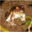

In [13]:
data[0][0]

In [14]:
transforms.ToTensor()(data[0][0])

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [15]:
data[0][1]

6

In [16]:
torch.Tensor(data[0][1]) 

tensor([0., 0., 0., 0., 0., 0.])

In [17]:
# -----------------------

In [13]:
class CustomDataset(Dataset):
    
    def __init__(self, train, transform=None, data_dir="./data/CIFAR_10"):  
        self.data = datasets.CIFAR10(root=data_dir, 
                                     train=train, 
                                     download=True) # True: 데이터 다운 받아서 root경로에 저장. 만약 이미 다운되어있으면 다시 다운받지 않음 
        self.transform = transform

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    def collate_fn(self, data): # 이미지 파일을 텐서로 바꾸기
        batch_x, batch_y = [], []
        for x, y in data:
            if self.transform is not None:
                x = self.transfom(x)
            x = transforms.ToTensor()(x) # 입력 데이터가 NumPy 배열 또는 PIL 이미지 형식인 경우 ToTensor를 사용하여 텐서 형식으로 변환 : (H, W, C) array를 (C, H, W) tensor로 변환
            y = torch.Tensor([y]) 
            batch_x.append(x)
            batch_y.append(y)
        # batch_x, batch_y를 list에서 tensor로 바꾸기
        batch_x = torch.stack(batch_x).float()
        batch_y = torch.cat(batch_y).long()
        return batch_x, batch_y

In [14]:
BATCH_SIZE = 32
EPOCHS = 10

train_dataset = CustomDataset(train = True)
test_dataset = CustomDataset(train = False)

train_loader = DataLoader(dataset = train_dataset,
                          batch_size = BATCH_SIZE, 
                          shuffle = True, # training data는 항상 shuffle을 한다
                          collate_fn = train_dataset.collate_fn)

test_loader = DataLoader(dataset = test_dataset, 
                         batch_size = BATCH_SIZE, 
                         shuffle = False, 
                         collate_fn = test_dataset.collate_fn)

Files already downloaded and verified
Files already downloaded and verified


In [20]:
len(train_dataset), len(test_dataset)

(50000, 10000)

In [21]:
for X_train, y_train in train_dataset:
    print('X_train:', X_train, 'type:', type(X_train))
    print('y_train:', y_train, 'type:', type(y_train))
    break

X_train: <PIL.Image.Image image mode=RGB size=32x32 at 0x7F8E05B53220> type: <class 'PIL.Image.Image'>
y_train: 6 type: <class 'int'>


In [22]:
print(len(train_loader), len(test_loader))
print(len(train_dataset) / 32, len(test_dataset) / 32)

1563 313
1562.5 312.5


In [23]:
for (X_train, y_train) in train_loader:
    print('X_train:', X_train.size(), 'type:', X_train.type())
    print('y_train:', y_train.size(), 'type:', y_train.type())
    break

X_train: torch.Size([32, 3, 32, 32]) type: torch.FloatTensor
y_train: torch.Size([32]) type: torch.LongTensor


In [24]:
x = np.array(train_dataset[0][0])
print(x.shape)
print(transforms.ToTensor()(x).shape)

(32, 32, 3)
torch.Size([3, 32, 32])


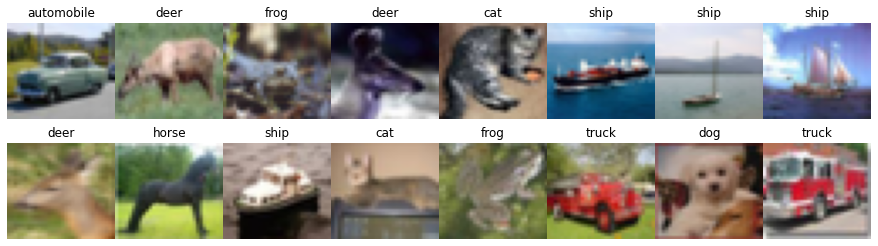

In [7]:
CIFAR_plot_dataset(train_loader)

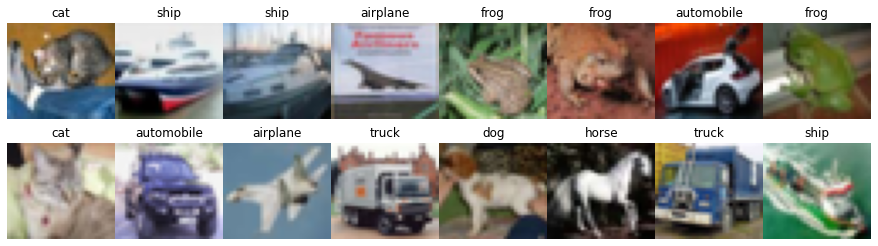

In [6]:
CIFAR_plot_dataset(test_loader)

In [ ]:
# ----- Utils -----

In [15]:
def train(model, train_loader, optimizer, scheduler=None):
    model.train()
    train_loss = 0
    correct = 0
    tqdm_bar = tqdm(enumerate(train_loader))
    for batch_idx, (image, label) in tqdm_bar:
        image = image.to(DEVICE)
        label = label.to(DEVICE)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        train_loss += loss.item()
        prediction = output.max(1, keepdim = True)[1]
        correct += prediction.eq(label.view_as(prediction)).sum().item()
        optimizer.step()
        tqdm_bar.set_description("Epoch {} - train loss: {:.6f}".format(epoch, loss.item()))
    if scheduler is not None:
        scheduler.step() # lr scheduler decays the learning rate every epoch
    train_loss /= len(train_loader.dataset)
    train_acc = 100. * correct / len(train_loader.dataset)
    return train_loss, train_acc


def evaluate(model, test_loader):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for image, label in tqdm(test_loader):
            image = image.to(DEVICE)
            label = label.to(DEVICE)
            output = model(image)
            test_loss += criterion(output, label).item()
            prediction = output.max(1, keepdim = True)[1]
            correct += prediction.eq(label.view_as(prediction)).sum().item()
    
    test_loss /= len(test_loader.dataset)
    test_acc = 100. * correct / len(test_loader.dataset)
    return test_loss, test_acc

In [16]:
# ----- MLP -----

In [17]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(-1, 32 * 32 * 3)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        x = F.softmax(x, dim = 1)
        return x

In [18]:
model = MLP().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print(model)

MLP(
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


In [ ]:
for epoch in range(1, EPOCHS + 1):
    train(model, train_loader, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tModel: MLP, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, test_loss, test_accuracy))

In [61]:
# ----- CNN -----

In [29]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 8, kernel_size = 3)
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = 3)
        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.fc1 = nn.Linear(6 * 6 * 16, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 10)
        
    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
        
        x = x.view(-1, 6 * 6 * 16)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        # x = F.softmax(x) -> PyTorch에서는 softmax와 CrossEntropyLoss를 합쳐놓은 것을 제공하기 때문에 맨 마지막 layer가 softmax일 필요가 없음
        return x

In [30]:
model = CNN().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()

print(model)

CNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=576, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=10, bias=True)
)


In [31]:
# CNN: MLP에 비해 결과가 좋음. parameter 수가 적음에도 불구하고 성능이 더 좋음
for epoch in range(1, EPOCHS + 1):
    train(model, train_loader, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tModel: CNN, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, test_loss, test_accuracy))



[EPOCH: 1], 	Model: CNN, 	Test Loss: 0.0471, 	Test Accuracy: 45.46 % 





[EPOCH: 2], 	Model: CNN, 	Test Loss: 0.0425, 	Test Accuracy: 50.76 % 





[EPOCH: 3], 	Model: CNN, 	Test Loss: 0.0421, 	Test Accuracy: 52.16 % 





[EPOCH: 4], 	Model: CNN, 	Test Loss: 0.0384, 	Test Accuracy: 56.38 % 





[EPOCH: 5], 	Model: CNN, 	Test Loss: 0.0369, 	Test Accuracy: 58.20 % 





[EPOCH: 6], 	Model: CNN, 	Test Loss: 0.0364, 	Test Accuracy: 58.75 % 





[EPOCH: 7], 	Model: CNN, 	Test Loss: 0.0360, 	Test Accuracy: 58.76 % 





[EPOCH: 8], 	Model: CNN, 	Test Loss: 0.0355, 	Test Accuracy: 59.71 % 





[EPOCH: 9], 	Model: CNN, 	Test Loss: 0.0356, 	Test Accuracy: 59.74 % 





[EPOCH: 10], 	Model: CNN, 	Test Loss: 0.0342, 	Test Accuracy: 61.07 % 



In [36]:
# ----- CNN: model search -----

In [80]:
# 모델 정의
class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()
        self.conv = nn.Sequential(
#             # first try
#             nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size = 2, stride = 2),
#             nn.Flatten(),
#             nn.Linear(8*16*16, 10)            
            
            # second try
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=5),
            nn.ReLU(),
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            nn.Flatten(),
            nn.Linear(16*12*12, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )
        
    def forward(self, x):
        x = self.conv(x)
        return x

In [81]:
# layer를 적용한 뒤 input shape이 어떻게 바뀌는 지 확인
x = torch.randn(32, 3, 32, 32)
print(x.shape)
x = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1)(x)
print(x.shape)
x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
print(x.shape)

torch.Size([32, 3, 32, 32])
torch.Size([32, 8, 32, 32])
torch.Size([32, 8, 16, 16])


In [82]:
x = torch.randn(32, 3, 32, 32)
print(x.shape)
x = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=5)(x)
print(x.shape)
x = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5)(x)
print(x.shape)
x = nn.MaxPool2d(kernel_size = 2, stride = 2)(x)
print(x.shape)

torch.Size([32, 3, 32, 32])
torch.Size([32, 8, 28, 28])
torch.Size([32, 16, 24, 24])
torch.Size([32, 16, 12, 12])


In [62]:
model = MyCNN().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()

# lr scheduler
from torch.optim.lr_scheduler import ExponentialLR as ExponentialLR
scheduler = ExponentialLR(optimizer, gamma=0.9)

print(model)

MyCNN(
  (conv): Sequential(
    (0): Conv2d(3, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=2304, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [63]:
# 모델 학습 및 결과 확인
for epoch in range(1, EPOCHS + 1):
    train(model, train_loader, optimizer, scheduler)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tModel: MY CNN, \tLR: {:.4f}, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, scheduler.get_last_lr()[0], test_loss, test_accuracy))



[EPOCH: 1], 	Model: MY CNN, 	LR: 0.0009, 	Test Loss: 0.0017, 	Test Accuracy: 39.68 % 





[EPOCH: 2], 	Model: MY CNN, 	LR: 0.0008, 	Test Loss: 0.0016, 	Test Accuracy: 43.80 % 





[EPOCH: 3], 	Model: MY CNN, 	LR: 0.0007, 	Test Loss: 0.0014, 	Test Accuracy: 48.16 % 





[EPOCH: 4], 	Model: MY CNN, 	LR: 0.0007, 	Test Loss: 0.0014, 	Test Accuracy: 50.44 % 





[EPOCH: 5], 	Model: MY CNN, 	LR: 0.0006, 	Test Loss: 0.0013, 	Test Accuracy: 52.25 % 

